# Human Development Index (HDI) &mdash; Exploratory Data Analysis & Modeling

**Project:** A Comprehensive Measure of Well-Being: HDI Prediction

This notebook walks through the full data-science workflow for predicting a
country's HDI Category (`Low`, `Medium`, `High`, `Very High`) from four
indicators: Life Expectancy, Mean Years of Schooling, Expected Years of
Schooling, and GNI Per Capita.

**Contents**
1. Load & inspect the data
2. Data cleaning (missing values, duplicates)
3. Statistical summary & correlation analysis
4. Visualizations (distributions, box plots, pair plots, heatmap)
5. Outlier detection
6. Preprocessing (encoding, scaling, train/test split)
7. Model training & comparison
8. Model evaluation (confusion matrix, ROC, learning curve, cross-validation)
9. Feature importance
10. Saving the final model


In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 1. Load the Dataset

We load `HDI.csv`. The loader below auto-detects the target column name so
this notebook keeps working even if you swap in a differently-formatted HDI
dataset (e.g. the official UNDP export).


In [2]:
df = pd.read_csv("HDI.csv")

CANDIDATE_TARGET_NAMES = ["HDI Category", "hdi_category", "Category", "Target"]
target_col = next((c for c in CANDIDATE_TARGET_NAMES if c in df.columns), None)
if target_col is None:
    target_col = next(c for c in df.columns if df[c].dtype == object and df[c].nunique() <= 6)
if target_col != "HDI Category":
    df = df.rename(columns={target_col: "HDI Category"})

df.head(10)


,Country,Life Expectancy,Mean Years of Schooling,Expected Years of Schooling,GNI Per Capita,HDI Score,HDI Category
0,Madagascar,73.2,8.2,12.5,9236.32,0.680,Medium
1,Togo,70.0,9.1,11.2,NaN,0.655,Medium
2,Guatemala,65.4,7.5,10.7,5706.57,0.596,Medium
3,Saudi Arabia,65.6,4.5,9.5,1673.13,0.482,Low
4,Estonia,72.4,8.2,11.1,6142.90,0.642,Medium
5,Iran,63.8,9.6,12.9,4901.18,0.624,Medium
6,Burundi,71.4,10.5,15.8,9228.56,0.728,High
7,Central African Republic,70.2,8.6,8.8,7352.22,0.622,Medium
8,Israel,73.7,7.9,12.7,34390.23,0.741,High
9,Japan,74.5,10.8,15.2,27081.23,0.795,High


### 1.1 Dataset Shape and Info

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (153, 7)
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      153 non-null    str    
 1   Life Expectancy              151 non-null    float64
 2   Mean Years of Schooling      152 non-null    float64
 3   Expected Years of Schooling  153 non-null    float64
 4   GNI Per Capita               150 non-null    float64
 5   HDI Score                    153 non-null    float64
 6   HDI Category                 153 non-null    str    
dtypes: float64(5), str(2)
memory usage: 8.5 KB


### 1.2 Missing Values

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})


,Missing Count,Missing %
Country,0,0.00
Life Expectancy,2,1.31
Mean Years of Schooling,1,0.65
Expected Years of Schooling,0,0.00
GNI Per Capita,3,1.96
HDI Score,0,0.00
HDI Category,0,0.00


### 1.3 Duplicate Rows

In [5]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(list(df.columns))


Duplicate rows: 3


,Country,Life Expectancy,Mean Years of Schooling,Expected Years of Schooling,GNI Per Capita,HDI Score,HDI Category
20,Burkina Faso,77.6,8.3,12.0,11176.58,0.704,High
146,Burkina Faso,77.6,8.3,12.0,11176.58,0.704,High
53,Honduras,69.8,10.2,15.4,20403.32,0.753,High
84,Honduras,69.8,10.2,15.4,20403.32,0.753,High
122,United Kingdom,80.0,11.4,15.4,37579.01,0.846,Very High
150,United Kingdom,80.0,11.4,15.4,37579.01,0.846,Very High


### 1.4 Data Types

In [6]:
df.dtypes

Country                            str
Life Expectancy                float64
Mean Years of Schooling        float64
Expected Years of Schooling    float64
GNI Per Capita                 float64
HDI Score                      float64
HDI Category                       str
dtype: object

## 2. Data Cleaning

We drop duplicate rows and fill missing numeric values with the column
median, which is robust to the outliers common in economic data like GNI.


In [7]:
FEATURE_COLUMNS = [
    "Life Expectancy",
    "Mean Years of Schooling",
    "Expected Years of Schooling",
    "GNI Per Capita",
]

df_clean = df.drop_duplicates().reset_index(drop=True)

for col in FEATURE_COLUMNS:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled {col} missing values with median = {median_val:.2f}")

df_clean = df_clean.dropna(subset=["HDI Category"]).reset_index(drop=True)
print("\nShape after cleaning:", df_clean.shape)


Filled Life Expectancy missing values with median = 68.40
Filled Mean Years of Schooling missing values with median = 8.20
Filled GNI Per Capita missing values with median = 9633.21

Shape after cleaning: (150, 7)


## 3. Statistical Summary

In [8]:
df_clean[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
Life Expectancy,150.0,68.784667,5.635765,56.20,64.8250,68.40,73.500,81.90
Mean Years of Schooling,150.0,8.033333,2.303999,1.60,6.7000,8.20,9.575,13.50
Expected Years of Schooling,150.0,12.734667,2.853374,5.90,10.8000,12.60,14.575,19.80
GNI Per Capita,150.0,15682.703600,18415.748535,615.51,4920.9525,9633.21,18832.415,105391.08


### 3.1 HDI Category Distribution

HDI Category
Medium       63
High         39
Low          29
Very High    19
Name: count, dtype: int64


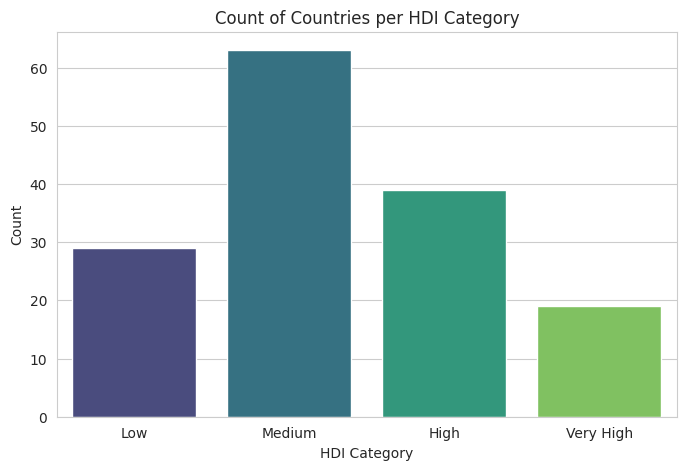

In [9]:
category_counts = df_clean["HDI Category"].value_counts()
print(category_counts)

plt.figure()
sns.countplot(data=df_clean, x="HDI Category",
              order=["Low", "Medium", "High", "Very High"], palette="viridis")
plt.title("Count of Countries per HDI Category")
plt.xlabel("HDI Category")
plt.ylabel("Count")
plt.show()


### 3.2 Correlation Analysis

In [10]:
corr = df_clean[FEATURE_COLUMNS].corr()
corr


,Life Expectancy,Mean Years of Schooling,Expected Years of Schooling,GNI Per Capita
Life Expectancy,1.000000,0.733184,0.736296,0.612733
Mean Years of Schooling,0.733184,1.000000,0.735415,0.486341
Expected Years of Schooling,0.736296,0.735415,1.000000,0.532328
GNI Per Capita,0.612733,0.486341,0.532328,1.000000


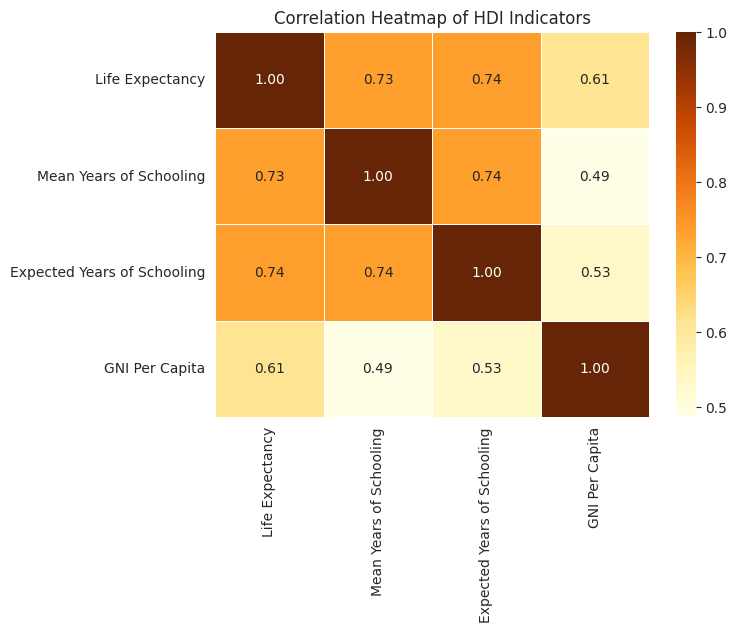

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="YlOrBr", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of HDI Indicators")
plt.show()


## 4. Distributions

Histograms show the spread of each feature; GNI Per Capita is typically
right-skewed since a small number of very wealthy countries pull the
average up.


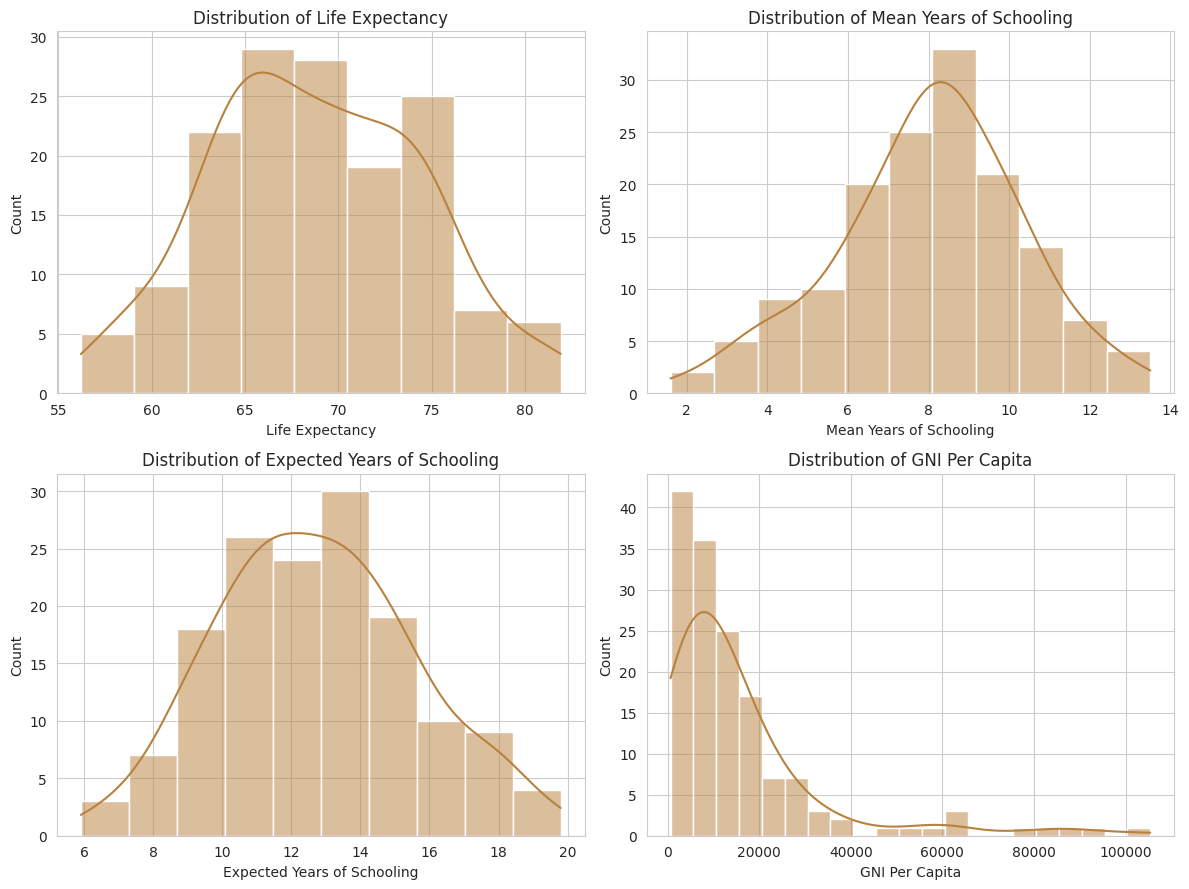

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="#B8813D")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### 4.1 Box Plots (Outlier Detection)

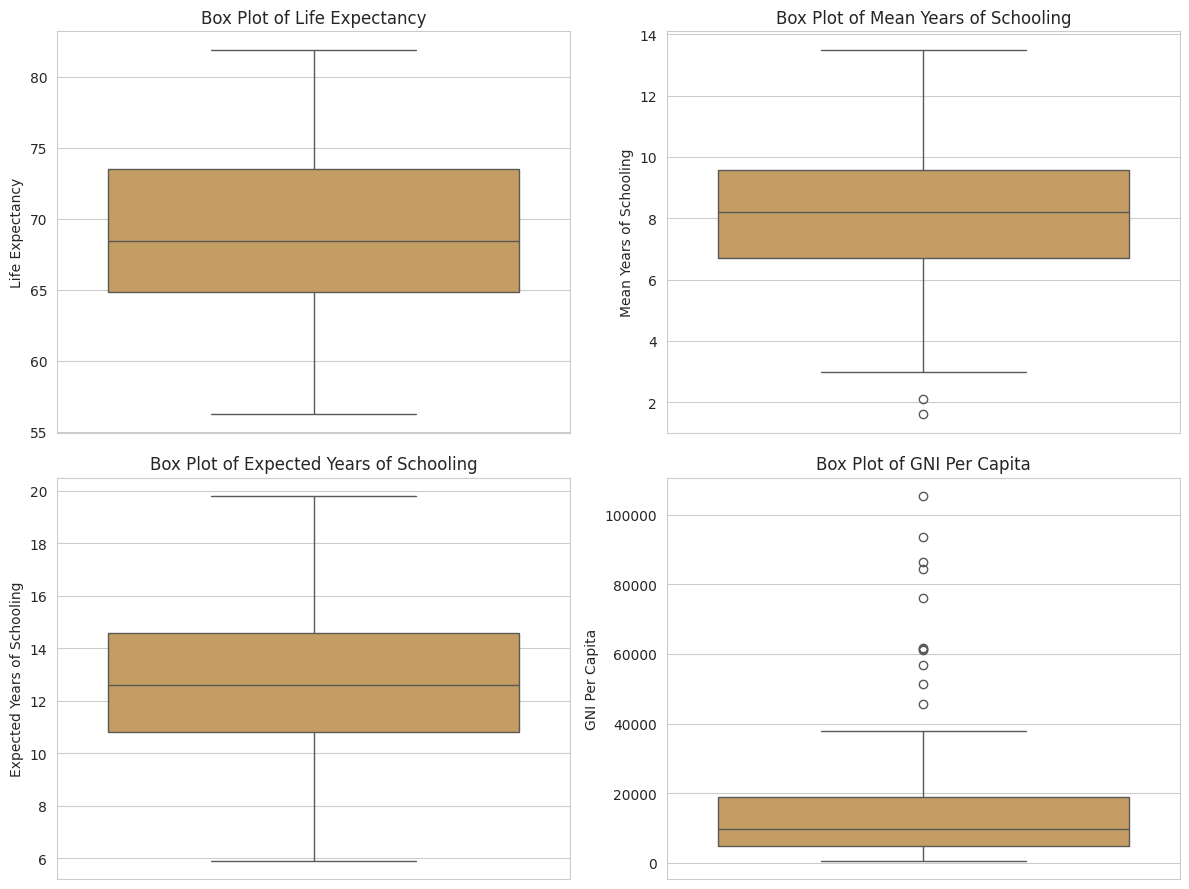

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.boxplot(y=df_clean[col], ax=ax, color="#D4A054")
    ax.set_title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()


In [14]:
# IQR-based outlier count per feature
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in FEATURE_COLUMNS:
    print(f"{col}: {count_outliers_iqr(df_clean[col])} potential outliers (IQR method)")


Life Expectancy: 0 potential outliers (IQR method)
Mean Years of Schooling: 2 potential outliers (IQR method)
Expected Years of Schooling: 0 potential outliers (IQR method)
GNI Per Capita: 11 potential outliers (IQR method)


### 4.2 Box Plots by HDI Category

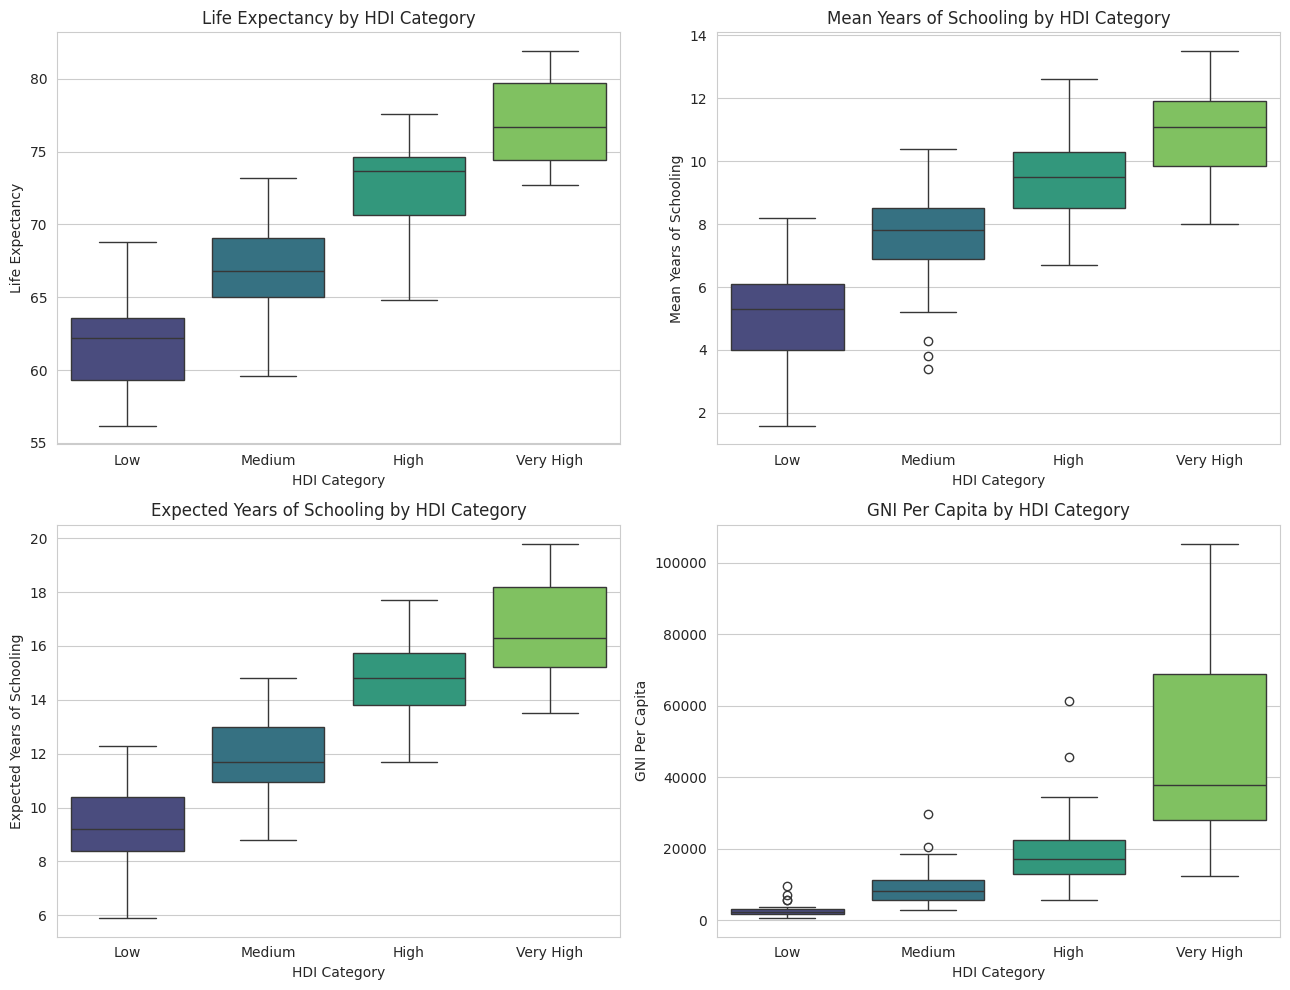

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
order = ["Low", "Medium", "High", "Very High"]
for ax, col in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.boxplot(data=df_clean, x="HDI Category", y=col, order=order, ax=ax, palette="viridis")
    ax.set_title(f"{col} by HDI Category")
plt.tight_layout()
plt.show()


### 4.3 Pair Plot

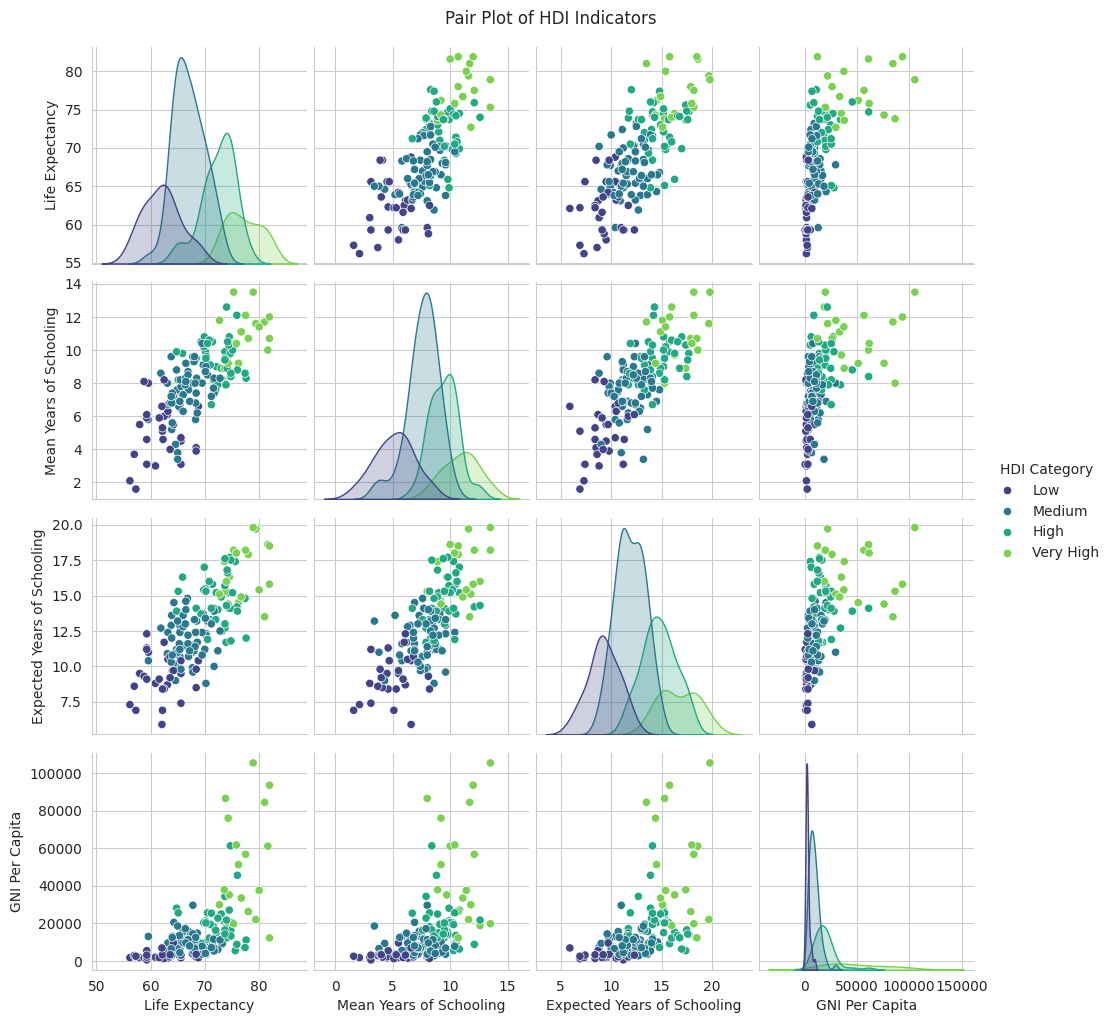

In [16]:
sns.pairplot(df_clean, vars=FEATURE_COLUMNS, hue="HDI Category",
             hue_order=["Low", "Medium", "High", "Very High"], palette="viridis", diag_kind="kde")
plt.suptitle("Pair Plot of HDI Indicators", y=1.02)
plt.show()


## 5. Preprocessing

Steps:
1. **Label Encoding** the target (`HDI Category` &rarr; integers).
2. **Feature Scaling** with `StandardScaler` so features with very different
   ranges (e.g. GNI in the thousands vs. schooling in single digits) contribute
   fairly to distance-based models like KNN and SVM.
3. **Train/Test Split** (80/20), stratified by class so every category is
   represented proportionally in both sets.


In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

X = df_clean[FEATURE_COLUMNS]
y_raw = df_clean["HDI Category"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("Encoded classes:", list(label_encoder.classes_))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Encoded classes: ['High', 'Low', 'Medium', 'Very High']
Train shape: (120, 4) | Test shape: (30, 4)


## 6. Model Training & Comparison

We train several classic classification algorithms and compare them on
Accuracy, Precision, Recall and F1 Score (weighted average, since classes
are imbalanced).


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
}
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(random_state=42, eval_metric="mlogloss", use_label_encoder=False)

results = []
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })
    trained[name] = model

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,SVM,0.900000,0.898462,0.900000,0.897455
2,Naive Bayes,0.900000,0.908832,0.900000,0.896314
3,KNN,0.866667,0.868832,0.866667,0.862721
4,XGBoost,0.800000,0.818333,0.800000,0.803463
5,Random Forest,0.800000,0.827222,0.800000,0.798942
6,Gradient Boosting,0.733333,0.745000,0.733333,0.733766
7,Decision Tree,0.666667,0.671667,0.666667,0.664069


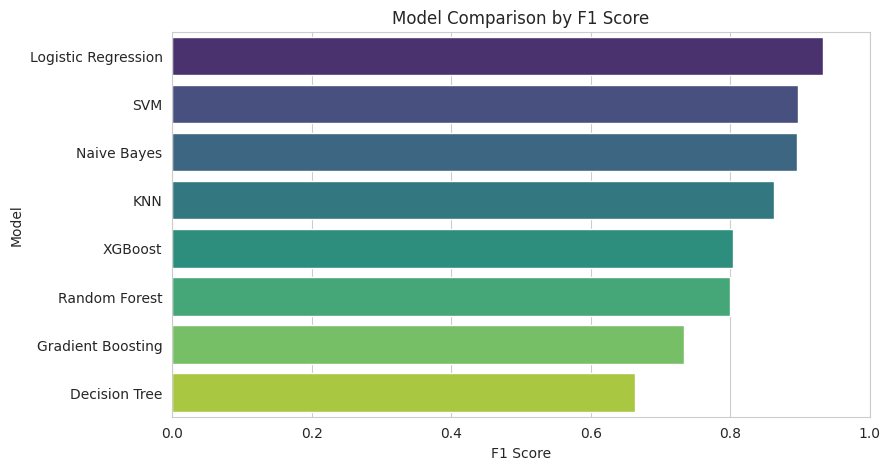

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1 Score", y="Model", palette="viridis")
plt.title("Model Comparison by F1 Score")
plt.xlim(0, 1)
plt.show()


### 6.1 Best Model Selection

In [20]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained[best_model_name]
print("Best model:", best_model_name)

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_, zero_division=0))


Best model: Logistic Regression
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       0.83      0.83      0.83         6
      Medium       0.92      0.92      0.92        12
   Very High       1.00      1.00      1.00         4

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



## 7. Model Evaluation

### 7.1 Confusion Matrix

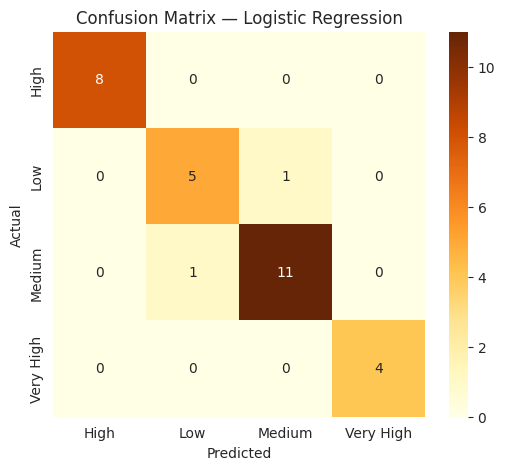

In [21]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


### 7.2 Cross-Validation Score

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring="f1_weighted")
print("Cross-validation F1 scores:", np.round(cv_scores, 4))
print("Mean CV F1 score:", round(cv_scores.mean(), 4))


Cross-validation F1 scores: [0.8652 0.9658 0.827  0.7248 0.8968]
Mean CV F1 score: 0.8559


### 7.3 Learning Curve

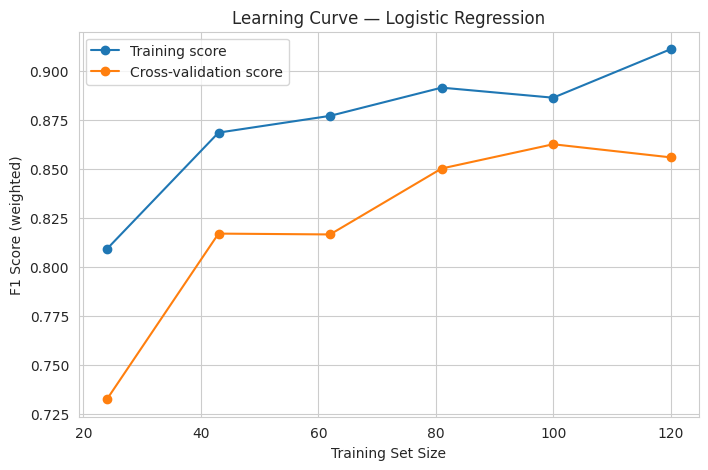

In [23]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_scaled, y, cv=5, scoring="f1_weighted",
    train_sizes=np.linspace(0.2, 1.0, 6)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(train_sizes, test_scores.mean(axis=1), "o-", label="Cross-validation score")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score (weighted)")
plt.title(f"Learning Curve — {best_model_name}")
plt.legend()
plt.show()


### 7.4 ROC Curve (One-vs-Rest)

Since this is a multi-class problem, we plot a One-vs-Rest ROC curve for
each HDI category (only meaningful for models exposing `predict_proba`).


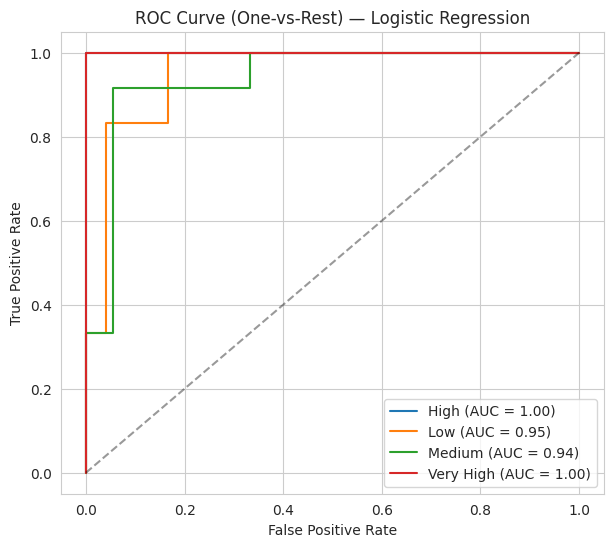

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

if hasattr(best_model, "predict_proba"):
    y_test_bin = label_binarize(y_test, classes=np.unique(y))
    y_score = best_model.predict_proba(X_test)

    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (One-vs-Rest) — {best_model_name}")
    plt.legend()
    plt.show()
else:
    print(f"{best_model_name} does not support predict_proba; skipping ROC curve.")


### 7.5 Feature Importance

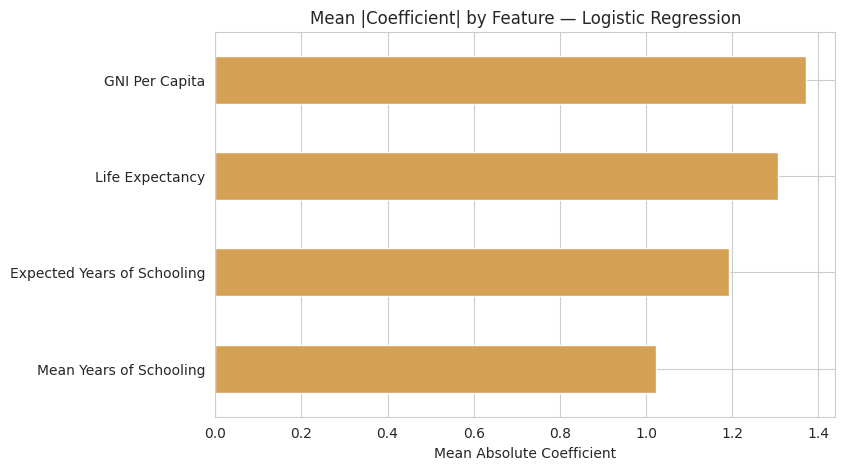

In [25]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS).sort_values()
    plt.figure()
    importances.plot(kind="barh", color="#D4A054")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.show()
elif hasattr(best_model, "coef_"):
    coef = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=FEATURE_COLUMNS).sort_values()
    plt.figure()
    coef.plot(kind="barh", color="#D4A054")
    plt.title(f"Mean |Coefficient| by Feature — {best_model_name}")
    plt.xlabel("Mean Absolute Coefficient")
    plt.show()
else:
    print(f"{best_model_name} does not expose feature importances directly.")


## 8. Save the Final Model

We persist the winning model, the fitted `StandardScaler`, and the
`LabelEncoder` with `joblib` so the Flask app (`app.py`) can load them
directly without retraining.


In [26]:
import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Saved model.pkl, scaler.pkl, label_encoder.pkl")


Saved model.pkl, scaler.pkl, label_encoder.pkl


## 9. Conclusion

- The dataset was cleaned (missing values imputed, duplicates removed).
- Four indicators (Life Expectancy, Mean/Expected Years of Schooling, GNI
  Per Capita) show strong correlation with HDI Category, as expected from
  the UNDP methodology.
- Multiple algorithms were compared; the best performing model (by F1
  Score) was automatically selected and saved for use in the Flask web app.
- Future improvements could include gathering more real-world training
  data, adding regional/continent features, and tuning hyperparameters via
  grid search or Bayesian optimization.
